# Socioeconomic Development and Environmental Performance

## Research Question

**How is socioeconomic development associated with environmental performance across countries?**

## Research Questions

1. Is economic prosperity associated with environmental performance?

2. Do countries with higher educational participation show higher environmental performance?

3. How is urbanization associated with environmental performance, and does this relationship differ across environmental dimensions such as air quality, waste management, and environmental health?

4. Are employment and unemployment rates associated with environmental performance?

5. Which countries perform substantially better or worse environmentally than their economic prosperity might suggest?

6. Which socioeconomic indicators show the strongest relationships with environmental performance?


### Predictive Modeling Question

Can socioeconomic indicators be used to predict a country's environmental performance?

## 1. Setup

Importing the libraries required for data manipulation and visualization.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Loading and Initial Inspection

### 2.1 Environmental Performance Index (EPI)

The EPI dataset is loaded and initially inspected to understand its structure, dimensions, and available environmental indicators.

In [2]:
epi = pd.read_excel("data/epi/epi2026results2026-07-07.xlsx", sheet_name="data")

In [3]:
epi.head(5)

,iso,country,EPI.new,HLT.new,AIR.new,PMD.new,HFD.new,OZD.new,NOD.new,COE.new,...,GRP.6,GRP.7,GRP.8,GRP.9,region,groupname,GDP,GPC,POP,LDA
0,AFG,Afghanistan,33.14,24.66,24.44,40.18,4.86,20.28,65.61,49.72,...,SWZ,TKM,UGA,CAF,Southern Asia,Landlocked Developing Countries,83.677383,1962.070438,42.647492,652230.0
1,ALB,Albania,49.22,48.67,37.37,32.07,38.77,60.79,60.26,62.46,...,SRB,ROU,HUN,BIH,Eastern Europe,Central European Initiative,51.443601,18950.592789,2.714617,27400.0
2,DZA,Algeria,42.74,50.96,54.83,14.37,100.00,29.89,47.85,44.50,...,SAU,EGY,OMN,ARE,Greater Middle East,Arab League,725.711643,15501.919700,46.814308,2381740.0
3,AGO,Angola,39.46,24.93,19.45,18.77,17.19,26.62,35.63,38.66,...,KIR,BFA,UGA,NPL,Sub-Saharan Africa,Least Developed Countries,337.255561,8901.887366,37.885849,1246700.0
4,ATG,Antigua & Barbuda,48.04,66.07,68.52,54.22,80.05,100.00,34.12,82.50,...,BHS,KNA,SUR,LCA,Latin America & Caribbean,Small Island Developing States,2.754237,29371.637779,0.093772,440.0


In [4]:
epi.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'PMD.new', 'HFD.new',
       'OZD.new', 'NOD.new', 'COE.new',
       ...
       'GRP.6', 'GRP.7', 'GRP.8', 'GRP.9', 'region', 'groupname', 'GDP', 'GPC',
       'POP', 'LDA'],
      dtype='str', length=422)

### 2.2 Selecting Relevant EPI Variables

The original EPI dataset contains 422 columns. For the initial analysis, variables related to overall environmental performance, environmental health, air quality, waste management, and geographical region are selected.

The original dataset is preserved, while the selected variables are stored separately for analysis.

In [5]:
relevant_columns = [
    "iso",
    "country",
    "EPI.new",
    "HLT.new",
    "AIR.new",
    "WMG.new",
    "region"
]

epi_analysis = epi[relevant_columns].copy()

In [6]:
epi_analysis.head()

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region
0,AFG,Afghanistan,33.14,24.66,24.44,56.20,Southern Asia
1,ALB,Albania,49.22,48.67,37.37,91.69,Eastern Europe
2,DZA,Algeria,42.74,50.96,54.83,40.00,Greater Middle East
3,AGO,Angola,39.46,24.93,19.45,43.89,Sub-Saharan Africa
4,ATG,Antigua & Barbuda,48.04,66.07,68.52,49.50,Latin America & Caribbean


### 2.3 Data Quality Check

The selected dataset is examined for its dimensions, data types, missing values, duplicate rows, and country coverage before further analysis.

In [7]:
epi_analysis.shape

(177, 7)

In [8]:
epi_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   iso      177 non-null    str    
 1   country  177 non-null    str    
 2   EPI.new  177 non-null    float64
 3   HLT.new  177 non-null    float64
 4   AIR.new  177 non-null    float64
 5   WMG.new  177 non-null    float64
 6   region   177 non-null    str    
dtypes: float64(4), str(3)
memory usage: 9.8 KB


In [9]:
print("Duplicate rows:", epi_analysis.duplicated().sum())
print("Unique countries:", epi_analysis["country"].nunique())

Duplicate rows: 0
Unique countries: 177


## 3. Socioeconomic Data

### 3.1 GDP per Capita

GDP per capita data from the World Bank is loaded as the first socioeconomic indicator. The first four metadata rows are skipped so that the dataset is read using its actual column headers.

In [10]:
gdp = pd.read_csv("data/world_bank/gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv", skiprows=4)

In [11]:
gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30654.485124,22664.370995,26827.344787,31000.571380,34897.618393,38590.565029,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089515,186.909365,197.367876,225.400456,208.963066,226.836513,...,1529.923080,1553.617944,1508.031525,1351.503167,1560.894626,1675.902524,1571.132704,1628.227289,1722.385620,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,416.871146,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.551510,155.587905,...,1577.203497,1723.114463,2219.412555,2034.437940,2116.938294,2143.072094,1846.246811,1416.228412,1600.058374,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2832.149980,2891.830324,2507.868072,1749.179484,2266.968349,3598.536691,2885.513491,2720.819007,3129.476623,NaN


#### Selecting the Reference Year

The most recent years are examined to determine which provides better data coverage for the analysis.

In [12]:
gdp['2024'].isna().sum()

np.int64(18)

In [13]:
gdp['2025'].isna().sum()

np.int64(32)

The 2024 column contains 18 missing values, compared with 32 in 2025. Therefore, 2024 is selected as the reference year because it provides more complete data coverage.

#### Selecting Relevant Variables

Only the country name, country code, and 2024 GDP per capita values are retained for the analysis. The country code will later be used to match the World Bank data with the EPI dataset.

In [14]:
relevant_gdp_columns = ['Country Name', 'Country Code', '2024']
gdp_analysis = gdp[relevant_gdp_columns].copy()

In [15]:
gdp_analysis.head()

,Country Name,Country Code,2024
0,Aruba,ABW,38590.565029
1,Africa Eastern and Southern,AFE,1628.227289
2,Afghanistan,AFG,416.871146
3,Africa Western and Central,AFW,1416.228412
4,Angola,AGO,2720.819007


#### Matching Countries with the EPI Dataset

World Bank country codes are compared with the ISO codes in the EPI dataset. This ensures that the GDP dataset contains only countries relevant to the environmental analysis and removes aggregate World Bank entries that do not represent individual EPI countries.

In [16]:
mask = gdp_analysis["Country Code"].isin(epi_analysis["iso"])
gdp_matched = gdp_analysis[mask]
gdp_matched

,Country Name,Country Code,2024
2,Afghanistan,AFG,416.871146
4,Angola,AGO,2720.819007
5,Albania,ALB,11374.008578
8,United Arab Emirates,ARE,50273.512624
9,Argentina,ARG,13969.783660
...,...,...,...
257,Vanuatu,VUT,3959.877035
259,Samoa,WSM,5392.877619
262,South Africa,ZAF,6267.186814
263,Zambia,ZMB,1187.109434


In [17]:
epi_analysis[~epi_analysis['iso'].isin(gdp['Country Code'])]

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region
155,TWN,Taiwan,46.02,60.11,48.86,97.88,Asia-Pacific


In [18]:
gdp_matched.isna().sum()

Country Name    0
Country Code    0
2024            0
dtype: int64

**Matching result:** 176 of the 177 EPI countries were successfully matched with the World Bank GDP data. Taiwan (TWN) was the only unmatched country. Among the 176 matched countries, no missing values were found for 2024 GDP per capita.

In [19]:
gdp_matched.rename(columns = {'2024': 'GDP_per_capita'}, inplace=True)

In [20]:
gdp_matched.columns

Index(['Country Name', 'Country Code', 'GDP_per_capita'], dtype='str')

In [21]:
gdp_matched.shape

(176, 3)

**GDP preparation result:** The final GDP dataset contains 176 matched countries and 3 variables. The 2024 GDP per capita values are complete for all matched countries, while Taiwan (TWN) remains unmatched with the World Bank data.

### 3.2 Education

Secondary school enrollment data from the World Bank is used as the education indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [22]:
education = pd.read_csv("data/world_bank/education/API_SE.SEC.ENRR_DS2_en_csv_v2_37594.csv", skiprows = 4)

In [23]:
education.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,137.829788,139.320587,135.124725,123.625908,131.802170,NaN,124.379367,NaN,NaN
1,Africa Eastern and Southern,AFE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,43.254089,43.559410,44.128731,44.682560,45.150532,45.281620,45.155392,45.606079,NaN,NaN
2,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,55.536430,57.357849,NaN,NaN,NaN,NaN,59.613602,NaN,NaN,NaN
3,Africa Western and Central,AFW,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,42.433170,42.714561,43.906269,44.734341,45.567429,45.637299,46.442242,46.300491,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,53.135154,NaN,51.483905,NaN,NaN,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the education indicator.

In [24]:
education[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     75
2021     72
2022     80
2023     74
2024    112
2025    256
dtype: int64

#### Matching Education Data with EPI Countries

The education dataset is filtered using ISO country codes to retain only countries included in the EPI dataset.

In [25]:
education_mask = education['Country Code'].isin(epi_analysis['iso'])
edu_matched = education[education_mask]
edu_matched

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
2,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,55.536430,57.357849,NaN,NaN,NaN,NaN,59.613602,NaN,NaN,NaN
4,Angola,AGO,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,53.135154,NaN,51.483905,NaN,NaN,NaN
5,Albania,ALB,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,97.574370,98.822388,99.015154,95.929447,97.665033,97.322471,96.136877,108.355392,NaN,NaN
8,United Arab Emirates,ARE,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102.184448,101.747344,99.163540,103.210663,102.380981,101.944972,102.129725,NaN,NaN
9,Argentina,ARG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,110.377800,109.671242,110.460152,112.376732,115.735779,114.148117,105.574584,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,Vanuatu,VUT,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,59.168800,62.943310,81.955128,134.670675,NaN,NaN,NaN
259,Samoa,WSM,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,105.623169,101.399613,103.789120,103.501178,106.443304,104.535067,104.133481,NaN,NaN,NaN
263,Zambia,ZMB,"School enrollment, secondary (% gross)",SE.SEC.ENRR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.788929,NaN,NaN


In [26]:
epi_analysis[~epi_analysis['iso'].isin(education['Country Code'])]

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region
155,TWN,Taiwan,46.02,60.11,48.86,97.88,Asia-Pacific


In [27]:
edu_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     48
2021     43
2022     53
2023     47
2024     86
2025    168
dtype: int64

#### Reference Year Selection

After matching the education data with the EPI countries, missing values were compared again across recent years. Although 2021 has the highest coverage, 2023 has only four additional missing values while providing more recent information. Therefore, 2023 was selected as the reference year.

In [28]:
relevant_edu_columns = ['Country Name', 'Country Code', '2023']

In [29]:
edu_analysis = edu_matched[relevant_edu_columns].copy()

In [30]:
edu_analysis.head()

,Country Name,Country Code,2023
2,Afghanistan,AFG,59.613602
4,Angola,AGO,51.483905
5,Albania,ALB,96.136877
8,United Arab Emirates,ARE,101.944972
9,Argentina,ARG,105.574584


In [31]:
edu_analysis.rename(columns = {'2023' : 'Secondary_enrollment'}, inplace = True)

In [32]:
edu_analysis.columns

Index(['Country Name', 'Country Code', 'Secondary_enrollment'], dtype='str')

In [33]:
edu_analysis['Secondary_enrollment'].isna().sum()

np.int64(47)

**Education preparation result:** The 2023 secondary school enrollment rate was selected as a balance between data recency and coverage. After matching with the EPI countries, 176 of 177 countries were successfully matched, with Taiwan (TWN) remaining unmatched. Among the matched countries, 47 education values are missing. Missing values are retained at this stage and will be handled after the datasets are merged.

### 3.3 Employment

Employment-to-population ratio data from the World Bank is used as the employment indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [34]:
employment = pd.read_csv('data/world_bank/employment/API_SL.EMP.TOTL.SP.ZS_DS2_en_csv_v2_200.csv', skiprows = 4)

In [35]:
employment.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,63.061750,62.630817,62.092583,60.693848,60.481732,61.172370,63.596635,63.661513,63.677295,NaN
2,Afghanistan,AFG,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.014000,40.466000,38.913000,36.710000,35.800000,32.333000,32.323000,32.408000,32.457000,NaN
3,Africa Western and Central,AFW,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,69.291064,69.054028,68.834907,67.356279,67.954659,69.388089,70.157119,70.104907,70.001283,NaN
4,Angola,AGO,"Employment to population ratio, 15+, total (%)...",SL.EMP.TOTL.SP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,63.045000,62.812000,62.644000,61.078000,64.306000,64.619000,64.369000,64.383000,64.236000,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the employment indicator.

In [36]:
employment[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    31
2021    31
2022    32
2023    34
2024    36
2025    36
dtype: int64

#### Matching Employment Data with EPI Countries

The employment dataset is filtered using ISO country codes to retain only countries included in the EPI dataset.

In [37]:
employment_mask = employment['Country Code'].isin(epi_analysis['iso'])
employment_matched = employment[employment_mask]
employment_matched.shape

(176, 71)

In [38]:
employment_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     7
2021     7
2022     8
2023     9
2024    10
2025    10
dtype: int64

#### Reference Year Selection

After matching the employment data with the EPI countries, missing values were compared again across recent years. Although earlier years have slightly fewer missing values, 2024 was selected because it provides more recent information while maintaining high country coverage.

In [39]:
relevant_emp_columns = ['Country Name', 'Country Code', '2024']
emp_analysis = employment_matched[relevant_emp_columns].copy()
emp_analysis.head()

,Country Name,Country Code,2024
2,Afghanistan,AFG,32.408
4,Angola,AGO,64.383
5,Albania,ALB,57.164
8,United Arab Emirates,ARE,76.789
9,Argentina,ARG,57.439


In [40]:
emp_analysis.rename(columns = {'2024' : 'Employment_rate'}, inplace = True)
emp_analysis.columns

Index(['Country Name', 'Country Code', 'Employment_rate'], dtype='str')

In [41]:
emp_analysis['Employment_rate'].isna().sum()

np.int64(10)

**Employment preparation result:** The 2024 employment-to-population ratio was selected as the employment indicator. After matching with the EPI countries, 176 of 177 countries were retained, and 10 employment values are missing. Missing values are kept at this stage and will be handled after the datasets are merged.

### 3.4 Unemployment

Unemployment data from the World Bank is used as the unemployment indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [42]:
unemployment = pd.read_csv('data/world_bank/unemployment/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_33398.csv', skiprows = 4)

In [43]:
unemployment.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.214915,7.244843,7.459106,7.974302,8.407412,7.869470,7.676548,7.571697,7.539233,NaN
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,11.192000,11.187000,11.710000,12.006000,14.100000,14.008000,13.687000,13.351000,NaN
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.284646,4.336100,4.393903,4.799306,4.670761,3.596538,3.203355,3.174915,3.192973,NaN
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.617000,16.602000,16.497000,16.696000,15.799000,14.124000,14.051000,14.020000,14.108000,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the unemployment indicator.

In [44]:
unemployment[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    31
2021    31
2022    32
2023    34
2024    36
2025    36
dtype: int64

#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the unemployment indicator.

In [45]:
unemployment_mask = unemployment['Country Code'].isin(epi_analysis['iso'])
unemployment_matched = unemployment[unemployment_mask]

In [46]:
unemployment_matched.shape

(176, 71)

In [47]:
unemployment_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020     7
2021     7
2022     8
2023     9
2024    10
2025    10
dtype: int64

#### Reference Year Selection

After matching the unemployment data with the EPI countries, missing values were compared again across recent years. Although earlier years have slightly fewer missing values, 2024 was selected because it provides more recent information while maintaining high country coverage.

In [48]:
relevant_unemp_columns = ['Country Name', 'Country Code', '2024']

In [49]:
unemp_analysis = unemployment_matched[relevant_unemp_columns].copy()

In [50]:
unemp_analysis.rename(columns = {'2024' : 'Unemployment'}, inplace = True)

In [51]:
unemp_analysis.head()

,Country Name,Country Code,Unemployment
2,Afghanistan,AFG,13.687
4,Angola,AGO,14.020
5,Albania,ALB,10.689
8,United Arab Emirates,ARE,2.160
9,Argentina,ARG,7.150


In [52]:
unemp_analysis['Unemployment'].isna().sum()

np.int64(10)

**Unemployment preparation result:** The 2024 unemployment rate was selected as the unemployment indicator. After matching with the EPI countries, 176 of 177 countries were retained, and 10 unemployment values are missing. Missing values are kept at this stage and will be handled after the datasets are merged.

### 3.5 Urban Population

Urban population data from the World Bank is used as the urbanization indicator. The dataset is first inspected to examine its structure, available years, and missing values.

In [53]:
urban_population = pd.read_csv('data/world_bank/urban_population/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_33901.csv', skiprows = 4)

In [54]:
urban_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,59.023670,59.072800,59.212271,59.432359,59.723340,60.075491,...,62.776849,62.536764,62.288276,62.002884,61.927534,61.881166,61.835149,61.790940,61.748525,NaN
1,Africa Eastern and Southern,AFE,Urban population (% of total population),SP.URB.TOTL.IN.ZS,14.640371,14.867730,15.107367,15.353899,15.607152,15.872246,...,35.282987,35.714718,36.097331,36.488322,36.908543,37.360578,37.772301,38.241441,38.702140,NaN
2,Afghanistan,AFG,Urban population (% of total population),SP.URB.TOTL.IN.ZS,8.122551,8.389595,8.662664,8.942709,9.231134,9.529343,...,24.835282,24.999165,25.143726,25.262210,25.347862,25.393925,25.473053,25.700735,25.940164,NaN
3,Africa Western and Central,AFW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,13.946480,14.468419,15.017383,15.592318,16.190616,16.814048,...,48.761009,49.332676,49.905469,50.492321,51.089419,51.700103,52.302109,52.878824,53.477205,NaN
4,Angola,AGO,Urban population (% of total population),SP.URB.TOTL.IN.ZS,10.387104,10.810545,11.207060,11.581720,11.945180,12.308095,...,65.085053,65.873214,66.663782,67.456827,68.252416,69.050619,69.851503,70.655138,71.461592,NaN


#### Missing Values Across Recent Years

Recent years are compared to evaluate data availability before selecting a reference year for the urban population indicator.

In [55]:
urban_population[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    1
2021    1
2022    1
2023    1
2024    1
2025    1
dtype: int64

#### Matching Urban Population Data with EPI Countries

The urban population dataset is filtered using ISO country codes to retain only countries included in the EPI dataset.

In [56]:
urban_mask = urban_population['Country Code'].isin(epi_analysis['iso'])
urban_matched = urban_population[urban_mask]

In [57]:
urban_matched.shape

(176, 71)

In [58]:
urban_matched[['2020', '2021', '2022', '2023', '2024', '2025']].isna().sum()

2020    0
2021    0
2022    0
2023    0
2024    0
2025    0
dtype: int64

#### Reference Year Selection

After matching the urban population data with the EPI countries, no missing values were found across the examined recent years. The year 2024 was selected to maintain consistency with the other socioeconomic indicators used in the analysis.

In [59]:
relevant_urban_columns = ['Country Name', 'Country Code', '2024']
urban_analysis = urban_matched[relevant_urban_columns].copy()

In [60]:
urban_analysis.rename(columns={'2024': 'Urban Population'}, inplace=True)

In [61]:
urban_analysis.shape

(176, 3)

In [62]:
urban_analysis['Urban Population'].isna().sum()

np.int64(0)

**Urban population preparation result:** The 2024 urban population rate was selected as the urbanization indicator. After matching with the EPI countries, 176 of 177 countries were retained, with no missing urban population values.

## 4. Data Integration

The prepared socioeconomic datasets are merged with the EPI dataset using ISO country codes. This creates a single country-level dataset containing environmental performance and development indicators for subsequent analysis.

### 4.1 Merging the Datasets

The prepared datasets are merged sequentially using country codes. The EPI dataset is used as the base, while the socioeconomic indicators are added one by one. After each merge, the dataset dimensions are checked to ensure that no unexpected country loss occurs.

In [63]:
merged_data = pd.merge(epi_analysis, gdp_analysis, left_on = 'iso', right_on = 'Country Code')

In [64]:
merged_data.shape

(176, 10)

In [65]:
merged_data.head()

,iso,country,EPI.new,HLT.new,AIR.new,WMG.new,region,Country Name,Country Code,2024
0,AFG,Afghanistan,33.14,24.66,24.44,56.20,Southern Asia,Afghanistan,AFG,416.871146
1,ALB,Albania,49.22,48.67,37.37,91.69,Eastern Europe,Albania,ALB,11374.008578
2,DZA,Algeria,42.74,50.96,54.83,40.00,Greater Middle East,Algeria,DZA,5752.990767
3,AGO,Angola,39.46,24.93,19.45,43.89,Sub-Saharan Africa,Angola,AGO,2720.819007
4,ATG,Antigua & Barbuda,48.04,66.07,68.52,49.50,Latin America & Caribbean,Antigua and Barbuda,ATG,23059.833070


In [66]:
merged_data.rename(columns={'2024': 'GDP'}, inplace=True)

In [67]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)   

In [68]:
merged_data.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'WMG.new', 'region',
       'GDP'],
      dtype='str')

In [69]:
merged_data = pd.merge(merged_data, edu_analysis, left_on = 'iso', right_on = 'Country Code')

In [70]:
merged_data.shape

(176, 11)

In [71]:
merged_data.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'WMG.new', 'region',
       'GDP', 'Country Name', 'Country Code', 'Secondary_enrollment'],
      dtype='str')

In [72]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [73]:
merged_data.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'WMG.new', 'region',
       'GDP', 'Secondary_enrollment'],
      dtype='str')

In [74]:
merged_data = pd.merge(merged_data, emp_analysis, left_on = 'iso', right_on = 'Country Code')

In [75]:
merged_data.shape

(176, 12)

In [76]:
merged_data.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'WMG.new', 'region',
       'GDP', 'Secondary_enrollment', 'Country Name', 'Country Code',
       'Employment_rate'],
      dtype='str')

In [77]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [78]:
merged_data = pd.merge(merged_data, unemp_analysis, left_on = 'iso', right_on = 'Country Code')

In [79]:
merged_data.shape

(176, 13)

In [80]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [81]:
merged_data.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'WMG.new', 'region',
       'GDP', 'Secondary_enrollment', 'Employment_rate', 'Unemployment'],
      dtype='str')

In [82]:
merged_data = pd.merge(merged_data, urban_analysis  , left_on = 'iso', right_on = 'Country Code')

In [83]:
merged_data.shape

(176, 14)

In [84]:
merged_data.drop(['Country Code', 'Country Name'], axis = 1, inplace = True)

In [85]:
merged_data.columns

Index(['iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'WMG.new', 'region',
       'GDP', 'Secondary_enrollment', 'Employment_rate', 'Unemployment',
       'Urban Population'],
      dtype='str')

### 4.2 Final Dataset Check

After integrating all selected indicators, the final dataset is inspected for its dimensions, column structure, and missing values before proceeding to exploratory data analysis.

In [86]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   iso                   176 non-null    str    
 1   country               176 non-null    str    
 2   EPI.new               176 non-null    float64
 3   HLT.new               176 non-null    float64
 4   AIR.new               176 non-null    float64
 5   WMG.new               176 non-null    float64
 6   region                176 non-null    str    
 7   GDP                   176 non-null    float64
 8   Secondary_enrollment  129 non-null    float64
 9   Employment_rate       166 non-null    float64
 10  Unemployment          166 non-null    float64
 11  Urban Population      176 non-null    float64
dtypes: float64(9), str(3)
memory usage: 16.6 KB


In [87]:
merged_data[['Secondary_enrollment', 'Employment_rate', 'Unemployment']].isna().any(axis = 1).sum()

np.int64(55)

#### Missing Value Strategy

Missing values are retained at this stage rather than removing entire observations. During exploratory analysis, each relationship will use the available observations for the relevant variables, preserving as much country-level information as possible. Missing-value imputation will be handled separately during the machine learning preprocessing stage.

## 5. Exploratory Data Analysis

This section explores the relationships between socioeconomic development and environmental performance across countries, following the research questions defined at the beginning of the analysis.

### 5.1 Economic Prosperity and Environmental Performance

**Research Question:** Is economic prosperity associated with environmental performance?

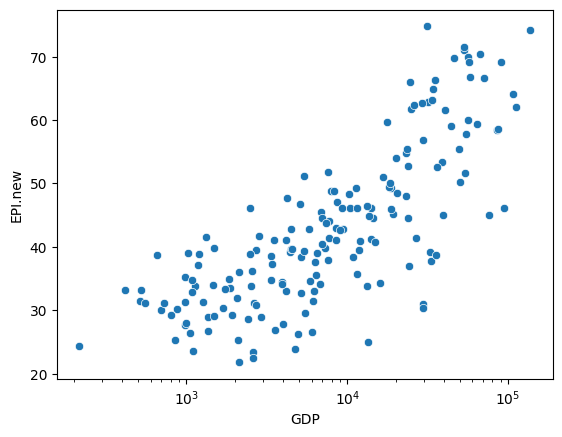

In [88]:
sns.scatterplot(x = 'GDP', y = 'EPI.new', data = merged_data)
plt.xscale('log')

In [89]:
merged_data[['GDP', 'EPI.new']].corr()

,GDP,EPI.new
GDP,1.000000,0.719201
EPI.new,0.719201,1.000000


In [90]:
np.log(merged_data['GDP'])

0       6.032777
1       9.339086
2       8.657475
3       7.908688
4      10.045848
         ...    
171     8.112964
172     8.283968
173     8.458856
174     7.079277
175     7.822507
Name: GDP, Length: 176, dtype: float64

In [91]:
np.log(merged_data['GDP']).corr(merged_data['EPI.new'])

np.float64(0.7765363900260518)

#### Findings

A clear positive association is observed between economic prosperity and environmental performance. The Pearson correlation between GDP per capita and EPI score is 0.719, indicating that countries with higher income levels tend to have higher environmental performance.

Because GDP per capita is strongly right-skewed, a logarithmic scale was used to better represent differences across income levels. After applying the log transformation, the correlation with EPI increased to 0.777, suggesting that the relationship is more linear when GDP is considered on a logarithmic scale.

These results indicate a strong association between economic prosperity and environmental performance, but they do not imply that higher GDP directly causes better environmental outcomes.

### 5.2 Education and Environmental Performance

**Research Question:** Do countries with higher educational participation show higher environmental performance?

<Axes: xlabel='Secondary_enrollment', ylabel='EPI.new'>

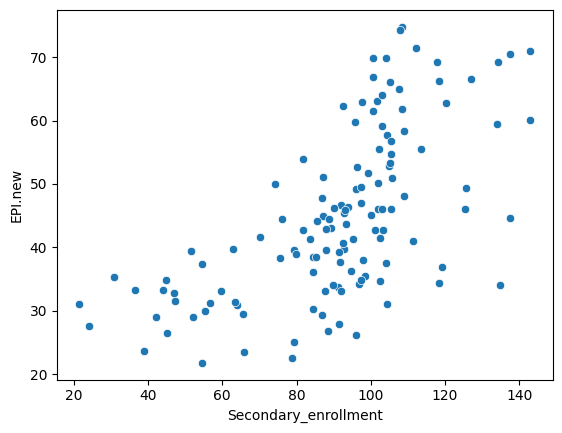

In [93]:
sns.scatterplot(x = 'Secondary_enrollment', y = 'EPI.new', data = merged_data)

In [94]:
merged_data[['Secondary_enrollment', 'EPI.new']].corr()

,Secondary_enrollment,EPI.new
Secondary_enrollment,1.000000,0.632583
EPI.new,0.632583,1.000000


#### Findings

Secondary school enrollment shows a positive association with environmental performance. The Pearson correlation between secondary enrollment and EPI score is 0.633, indicating a moderately strong positive relationship.

Countries with higher secondary enrollment rates generally tend to achieve higher environmental performance scores, although considerable variation remains across countries.

This analysis is based on the 129 countries with available secondary enrollment data, as countries with missing education values are excluded from the correlation calculation.

### 5.3 Labor Market and Environmental Performance

**Research Question:** Are employment and unemployment rates associated with environmental performance?

<Axes: xlabel='Employment_rate', ylabel='EPI.new'>

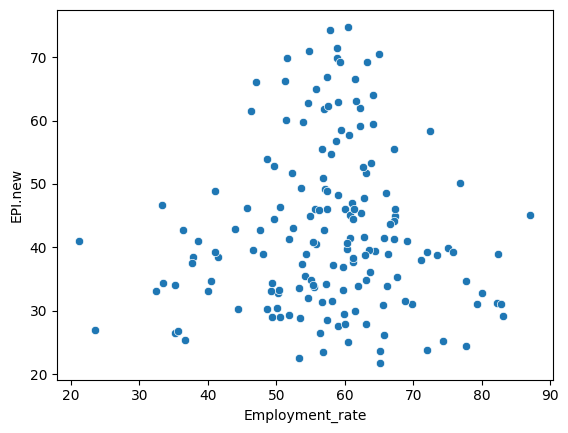

In [95]:
sns.scatterplot(x = 'Employment_rate', y = 'EPI.new', data = merged_data)

In [96]:
merged_data[['Employment_rate', 'EPI.new']].corr()

,Employment_rate,EPI.new
Employment_rate,1.000000,0.018522
EPI.new,0.018522,1.000000


<Axes: xlabel='Unemployment', ylabel='EPI.new'>

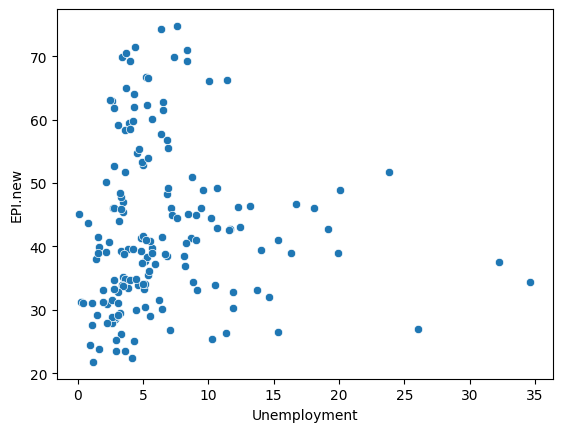

In [97]:
sns.scatterplot(x='Unemployment', y='EPI.new', data=merged_data)

In [98]:
merged_data[['Unemployment', 'EPI.new']].corr()

,Unemployment,EPI.new
Unemployment,1.000000,0.017362
EPI.new,0.017362,1.000000


#### Findings

Neither employment nor unemployment rates show a meaningful linear association with environmental performance.

The Pearson correlation between employment rate and EPI score is 0.019, while the correlation between unemployment rate and EPI score is 0.017. Both values are very close to zero, indicating little to no linear relationship with EPI in this dataset.

These results suggest that labor market indicators, when considered individually, are not strongly associated with differences in environmental performance across countries.

### 5.4 Urbanization and Regional Differences

**Research Question:** How is urbanization associated with environmental performance, and does this relationship differ across environmental dimensions such as air quality, waste management, and environmental health?

<Axes: xlabel='Urban Population', ylabel='EPI.new'>

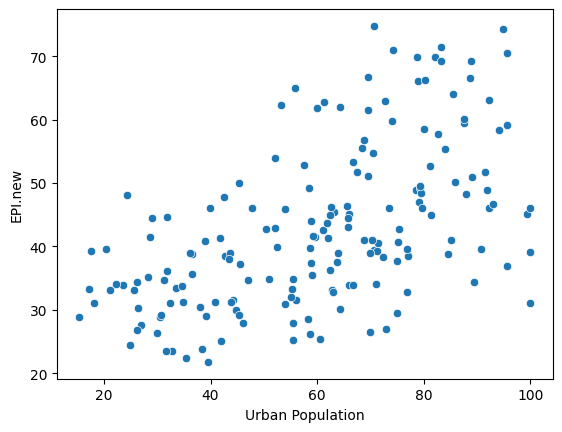

In [99]:
sns.scatterplot(x='Urban Population', y='EPI.new', data=merged_data)

In [100]:
merged_data[['Urban Population', 'EPI.new']].corr()

,Urban Population,EPI.new
Urban Population,1.000000,0.554904
EPI.new,0.554904,1.000000


In [101]:
merged_data[['Urban Population', 'AIR.new', 'WMG.new', 'HLT.new']].corr()

,Urban Population,AIR.new,WMG.new,HLT.new
Urban Population,1.000000,0.530993,0.564539,0.603519
AIR.new,0.530993,1.000000,0.594787,0.976988
WMG.new,0.564539,0.594787,1.000000,0.705151
HLT.new,0.603519,0.976988,0.705151,1.000000


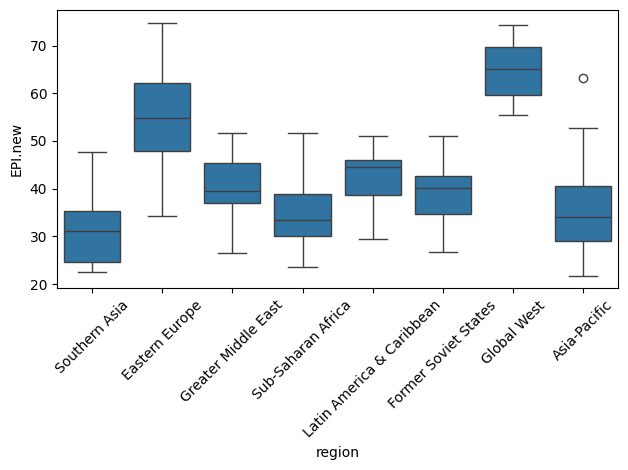

In [105]:
sns.boxplot(x='region', y='EPI.new', data = merged_data)
plt.xticks(rotation=45)
plt.tight_layout()

#### Findings

Urbanization shows a moderate positive association with environmental performance. The Pearson correlation between urban population share and EPI score is 0.555, suggesting that more urbanized countries tend to have higher environmental performance scores.

The relationship also varies across environmental dimensions. Urban population is positively correlated with air quality (r = 0.531), waste management (r = 0.565), and environmental health (r = 0.604), with the strongest association observed for environmental health.

Environmental performance also differs considerably across regions. The regional distributions show notably higher EPI scores in regions such as the Global West and Eastern Europe, while Southern Asia and Sub-Saharan Africa generally show lower scores. Considerable variation remains within several regions, indicating that regional classification alone does not fully explain differences in environmental performance.

### 5.5 Countries Performing Above or Below Economic Expectations

**Research Question:** Which countries perform substantially better or worse environmentally than their economic prosperity might suggest?

In [107]:
merged_data['log_GDP'] = np.log(merged_data['GDP'])
slope, intercept = np.polyfit(merged_data['log_GDP'], merged_data['EPI.new'], 1)

In [108]:
merged_data['Expected_EPI'] = (slope * merged_data['log_GDP']) + intercept

In [109]:
merged_data['Residual'] = merged_data['EPI.new'] - merged_data['Expected_EPI']

In [110]:
merged_data[['country', 'EPI.new', 'Expected_EPI', 'Residual']].sort_values(by = 'Residual', ascending = False).head(10)

,country,EPI.new,Expected_EPI,Residual
51,Estonia,74.79,52.600309,22.189691
168,United Kingdom,71.51,56.242677,15.267323
62,Greece,66.03,50.920954,15.109046
55,Finland,71.04,56.218656,14.821344
56,France,69.82,55.238574,14.581426
60,Germany,69.93,56.590328,13.339672
148,Spain,66.28,53.405419,12.874581
107,Mozambique,38.78,25.968930,12.811070
111,Netherlands,70.49,57.860069,12.629931
153,Sweden,69.20,56.726304,12.473696


In [111]:
merged_data[['country', 'EPI.new', 'Expected_EPI', 'Residual']].sort_values(by = 'Residual', ascending = True).head(10)

,country,EPI.new,Expected_EPI,Residual
67,Guyana,30.32,52.205108,-21.885108
97,Maldives,25.06,46.720213,-21.660213
11,Bahrain,31.05,52.214821,-21.164821
173,Viet Nam,23.82,39.541440,-15.721440
23,Brunei Darussalam,37.71,52.968243,-15.258243
75,Iraq,26.55,41.282423,-14.732423
137,Saudi Arabia,38.74,53.444488,-14.704488
142,Singapore,46.06,60.209179,-14.149179
170,Uruguay,36.91,50.831562,-13.921562
85,Kuwait,39.19,52.906126,-13.716126


In [117]:
top_positive = merged_data.sort_values(by='Residual', ascending = False).head(3)
top_negative = merged_data.sort_values(by='Residual', ascending = True).head(2)

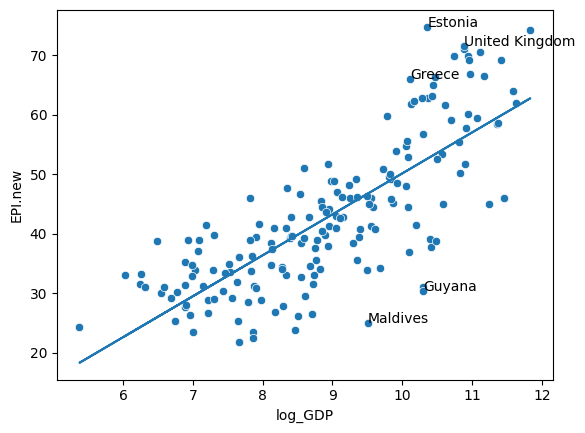

In [118]:
sns.scatterplot(x='log_GDP', y='EPI.new', data=merged_data)
plt.plot(merged_data['log_GDP'], merged_data['Expected_EPI'])
for index, row in top_positive.iterrows():
    plt.annotate(row['country'], (row['log_GDP'], row['EPI.new']))
for index, row in top_negative.iterrows():
    plt.annotate(row['country'], (row['log_GDP'], row['EPI.new']))

#### Findings

The residual analysis highlights countries whose environmental performance differs substantially from what would be expected based on their economic prosperity.

Estonia shows the largest positive residual, with an EPI score approximately 22 points higher than predicted by the relationship between log GDP and EPI. The United Kingdom and Greece also perform notably above their expected levels.

In contrast, Guyana and Maldives show the largest negative residuals, with EPI scores approximately 22 points below their predicted values.

These results show that economic prosperity alone does not fully explain environmental performance. Countries with similar economic conditions can still differ considerably in their environmental outcomes.

### 5.6 Overall Socioeconomic Relationships

**Research Question:** Which socioeconomic indicators show the strongest relationships with environmental performance?

In [119]:
merged_data[['log_GDP', 'Secondary_enrollment', 'Employment_rate', 'Unemployment', 'Urban Population', 'EPI.new']].corr()

,log_GDP,Secondary_enrollment,Employment_rate,Unemployment,Urban Population,EPI.new
log_GDP,1.000000,0.748898,0.036290,-0.032373,0.674137,0.776536
Secondary_enrollment,0.748898,1.000000,-0.088419,0.167646,0.525497,0.632583
Employment_rate,0.036290,-0.088419,1.000000,-0.606979,0.022838,0.018522
Unemployment,-0.032373,0.167646,-0.606979,1.000000,0.065806,0.017362
Urban Population,0.674137,0.525497,0.022838,0.065806,1.000000,0.554904
EPI.new,0.776536,0.632583,0.018522,0.017362,0.554904,1.000000


#### Findings

Among the socioeconomic indicators examined, log-transformed GDP shows the strongest positive relationship with environmental performance (r = 0.777).

Secondary school enrollment also shows a relatively strong positive relationship with EPI (r = 0.633), followed by urban population (r = 0.555).

In contrast, employment and unemployment rates show almost no linear relationship with EPI, with correlations close to zero.

Overall, economic prosperity, educational participation, and urbanization show stronger associations with environmental performance than labor market indicators in this dataset.